# Hierarchischer Planer – Projekt (lectures‑aware)

In [3]:

import sys, os, math, time, random
for cand in (".","./lectures","./planners","./utils","/mnt/data/lectures","/mnt/data/planners","/mnt/data/utils"):
    if os.path.isdir(cand) and cand not in sys.path:
        sys.path.insert(0, cand)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from hierarchical_planner_full import HierarchicalPlanner
from environments import env_maze, env_bugtrap, env_clutter

print("imports ok")


imports ok


## 2D Demo

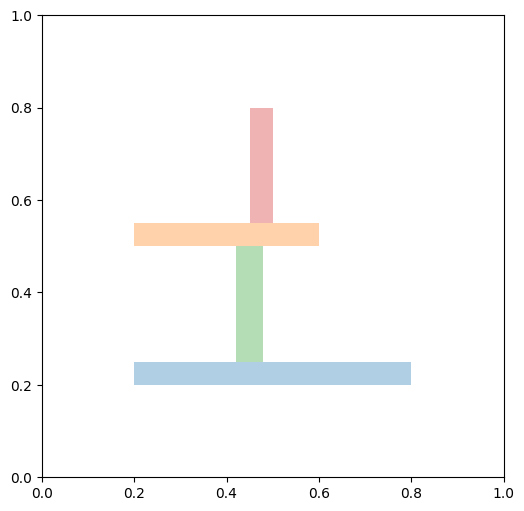

Pfadlänge: nan


In [4]:

cc = env_maze()
start=(0.05,0.05); goal=(0.95,0.95)
hp = HierarchicalPlanner(cc, internal="lazy", internal_budget=800, internal_k=16, internal_step=0.02, vis_ntry=15000, prefer_lectures=True)
path = hp.plan(start, goal)

fig, ax = plt.subplots(figsize=(6,6))
for poly in cc.obstacles:
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, alpha=0.35)
ax.set_xlim(cc.bounds[0], cc.bounds[2]); ax.set_ylim(cc.bounds[1], cc.bounds[3]); ax.set_aspect('equal')
if path:
    ax.plot([p[0] for p in path], [p[1] for p in path], linewidth=2)
    ax.scatter([start[0], goal[0]],[start[1], goal[1]])
plt.show()
print("Pfadlänge:", path_length(path))


In [ ]:
hp = HierarchicalPlanner(scene, limits, internal="lazy",
                         vis_ntry=8000, basic_radius=3.0, basic_nodes=600,
                         lazy_initial=250, lazy_k=18, lazy_update=120, lazy_max_iter=25)
path_xy = hp.plan(start, goal)

# High-Level (identische Optik zur 0.3-Darstellung)
ax = visualize_visibility(hp.global_planner, hp.global_solution_nodes)
ax.set_title(f"Hierarchical – High Level (Visibility) – {name}"); plt.show()

# Low-Level (erstes Segment – identische Optik 0.1/0.2)
if hp.segment_planners:
    ax = (visualize_lazy if hp.internal=='lazy' else visualize_basic)(hp.segment_planners[0], None)
    ax.set_title(f"Hierarchical – First Segment ({hp.internal.upper()}) – {name}"); plt.show()

# Animation im selben Look (grüner Pfadpunkt, Hindernisse gefüllt, Gitter)
if path_xy:
    ani, fig, ax = animate_path_vl_style(scene, limits, path_xy, title=f"Hierarchical Path – {name}", interval=60)
    from IPython.display import HTML; HTML(ani.to_jshtml())
